This notebook is for model2 training (5 representative households in dim 140 are used for training and two(seen and unseen households) types of testing sets where we use both autoregressive rolling based testing for 30 day forecast and 7 days input 1 day forecast.)

1. First part is training, which is same in model 1 as before with exception that we choose 5 representative households ['uk_MAC004809', 'uk_MAC004916', 'uk_MAC005385', 'uk_MAC004179', 'uk_MAC000507'] for training purposes.
2. There are two types of sets we use for performance, seen household test set and unseen households (same as before).
3. We use two MSE calculation methods, 7 days input-1 day forecast (calculated over one time step sliding for all times) and fixed 30 days term forecasting on an autoregressive rolling basis (calculated over 48 time step slides on limited time period.) the details of these calculations were explained in "model1_autoregressive_30days_forecast.ipynb" and  "model1_7days_inpuy1day_forecast.ipynb".



In [ ]:
# add data path there
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# change with the data path
df = pd.read_csv('/content/drive/My Drive/uk_data_clean.csv')

In [ ]:
pivoted = df.pivot(index='datetime', columns='id', values='target')

def dtarg(x):
  return(pd.to_datetime(x,format='%Y-%m-%d %H:%M:%S'))

pivoted.index = pivoted.index.map(dtarg)

np.random.seed(216)

testcols = np.random.choice(pivoted.columns, size=int((len(pivoted.columns)*.2)//1), replace=False, p=None)
traincols = [x for x in pivoted.columns if x not in testcols]

energy = pivoted[traincols]
energy_testing_set = pivoted[testcols]

In [ ]:
energy_testing_set.columns

Index(['uk_MAC003375', 'uk_MAC004019', 'uk_MAC003901', 'uk_MAC002320',
       'uk_MAC002547', 'uk_MAC001857', 'uk_MAC003796', 'uk_MAC003081',
       'uk_MAC000714', 'uk_MAC003958',
       ...
       'uk_MAC000742', 'uk_MAC002753', 'uk_MAC003397', 'uk_MAC001665',
       'uk_MAC004449', 'uk_MAC003082', 'uk_MAC005341', 'uk_MAC005162',
       'uk_MAC001869', 'uk_MAC000769'],
      dtype='object', name='id', length=183)

In [ ]:
energy.columns

Index(['uk_MAC000010', 'uk_MAC000018', 'uk_MAC000019', 'uk_MAC000027',
       'uk_MAC000034', 'uk_MAC000048', 'uk_MAC000049', 'uk_MAC000057',
       'uk_MAC000075', 'uk_MAC000091',
       ...
       'uk_MAC005475', 'uk_MAC005480', 'uk_MAC005508', 'uk_MAC005525',
       'uk_MAC005526', 'uk_MAC005527', 'uk_MAC005539', 'uk_MAC005540',
       'uk_MAC005545', 'uk_MAC005549'],
      dtype='object', name='id', length=736)

In [ ]:
pivot = energy.copy()

In [ ]:
# Choosing 5 representative households from dim 140 cluster.
selected_ids = ['uk_MAC004809', 'uk_MAC004916', 'uk_MAC005385', 'uk_MAC004179', 'uk_MAC000507']
pivot = pivot[selected_ids]

In [ ]:
pivot

id,uk_MAC004809,uk_MAC004916,uk_MAC005385,uk_MAC004179,uk_MAC000507
datetime,,,,,
2012-11-01 00:00:00,0.123,0.028,0.118,2.397,0.229
2012-11-01 00:30:00,0.125,0.056,3.898,1.693,0.270
2012-11-01 01:00:00,0.128,0.024,3.856,1.751,0.266
2012-11-01 01:30:00,0.162,0.030,3.189,1.846,0.256
2012-11-01 02:00:00,0.166,0.049,2.555,1.738,0.075
...,...,...,...,...,...
2013-11-30 21:30:00,0.390,0.147,0.152,1.674,0.236
2013-11-30 22:00:00,0.434,0.152,0.163,1.839,0.260
2013-11-30 22:30:00,0.485,0.159,0.190,1.727,0.256


In [ ]:
# Time features
tf = pd.DataFrame(index=pivot.index)
tf['hour'] = pivot.index.hour + pivot.index.minute / 60
tf['dow'] = pivot.index.dayofweek
tf['month'] = pivot.index.month

# Cyclical encoding, this way model understands how close 23:30 and 00:30 are...., we could possible have remove month versions.
import numpy as np
tf['hour_sin'] = np.sin(2 * np.pi * tf['hour'] / 24)
tf['hour_cos'] = np.cos(2 * np.pi * tf['hour'] / 24)
tf['dow_sin'] = np.sin(2 * np.pi * tf['dow'] / 7)
tf['dow_cos'] = np.cos(2 * np.pi * tf['dow'] / 7)
tf['month_sin'] = np.sin(2 * np.pi * tf['month'] / 12)
tf['month_cos'] = np.cos(2 * np.pi * tf['month'] / 12)

time_features = tf[['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']].values

In [ ]:
pivot.shape[0]

18960

In [ ]:
input_window = 7 * 48       # 336
forecast_horizon = 1 * 48   # 48

total_samples = pivot.shape[0] - input_window - forecast_horizon

# Create raw data splits before scaling
split1 = int(0.7 * total_samples)
split2 = int(0.85 * total_samples)

train_end = split1 + input_window + forecast_horizon
val_end = split2 + input_window + forecast_horizon

# Raw splits, unscaled
pivot_np = pivot.values
train_raw = pivot_np[:train_end]
val_raw   = pivot_np[train_end:val_end]
test_raw  = pivot_np[val_end:]

In [ ]:
train_raw.shape

(13387, 5)

In [ ]:
val_raw.shape

(2786, 5)

In [ ]:
test_raw.shape

(2787, 5)

In [ ]:
# Fit scaler on training data
scaler = MinMaxScaler()
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

# Time features must also be split accordingly
tf_train = time_features[:train_end]
tf_val   = time_features[train_end:val_end]
tf_test  = time_features[val_end:]

In [ ]:
# Sequence creation function
def create_sequences(data, time_feats, input_window, forecast_horizon):
    X, y = [], []
    num_households = data.shape[1]
    for c in range(num_households):
        series = data[:, c]
        for i in range(len(series) - input_window - forecast_horizon):
            hist = series[i:i+input_window]
            tf_hist = time_feats[i:i+input_window, :]
            X.append(np.hstack([hist.reshape(-1, 1), tf_hist]))
            y.append(series[i+input_window:i+input_window+forecast_horizon].reshape(-1, 1))
    return np.array(X), np.array(y)

# Build sequences for each set
X_train, y_train = create_sequences(train_scaled, tf_train, input_window, forecast_horizon)
X_val, y_val     = create_sequences(val_scaled, tf_val, input_window, forecast_horizon)
X_test, y_test   = create_sequences(test_scaled, tf_test, input_window, forecast_horizon)

print("X_train shape:", X_train.shape)  # (samples, 336, 7)
print("y_train shape:", y_train.shape)  # (samples, 48, 1)

X_train shape: (65015, 336, 7)
y_train shape: (65015, 48, 1)


In [ ]:
print("X_val shape:", X_val.shape)  # (samples, 336, 7)
print("y_val shape:", y_val.shape)  # (samples, 48, 1)
print("X_test shape:", X_test.shape)  # (samples, 336, 7)
print("y_test shape:", y_test.shape)  # (samples, 48, 1)

X_val shape: (12010, 336, 7)
y_val shape: (12010, 48, 1)
X_test shape: (12015, 336, 7)
y_test shape: (12015, 48, 1)


In [ ]:
# LSTM model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

model = Sequential([
    LSTM(64, input_shape=(input_window, X_train.shape[2])),
    RepeatVector(forecast_horizon),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(1))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 48, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 48, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=2,
    batch_size=8,
    verbose=1
)

Epoch 1/2
8127/8127 ━━━━━━━━━━━━━━━━━━━━ 157s 19ms/step - loss: 0.0119 - val_loss: 0.0052
Epoch 2/2
8127/8127 ━━━━━━━━━━━━━━━━━━━━ 209s 20ms/step - loss: 0.0069 - val_loss: 0.0049


In [ ]:
# update the path accordingly
# model.save('/content/drive/My Drive/dim140_k_5_lstm_energy_model.h5')


In [ ]:
# load the model 
# from tensorflow.keras.models import load_model

# model = load_model('/content/drive/My Drive/dim140_k_5_lstm_energy_model.h5', compile=False)


In [ ]:
# model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 48, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 48, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

We firstly calculate autoregressive rolling based 30-days fixed forecast for model 2. 

Firstly, for test set of seen households: 

In [ ]:
def rolling_day_forecast_autoregressive(test_data_scaled, time_feats_scaled, model, scaler, input_window=336, horizon=48, total_days=30):
    predictions = []
    actuals = []

    for h in range(test_data_scaled.shape[1]):  # For each household
        pred_h = []

        series = test_data_scaled[:, h]  # (num_timesteps,)
        tf_series = time_feats_scaled    # (num_timesteps, num_time_feats)

        # Initialize input with actual data (first 7 days)
        curr_input = series[:input_window].tolist()

        # To compare with true values later
        true_values_full = series[input_window:input_window + total_days * horizon]
        data_min = scaler.data_min_[h]
        data_max = scaler.data_max_[h]

        for i in range(total_days):
            start_idx = i * horizon
            tf_input = tf_series[start_idx:start_idx + input_window]

            input_combined = np.hstack([
                np.array(curr_input[-input_window:]).reshape(-1, 1),  # shape (336, 1)
                tf_input                                              # shape (336, 6)
            ])

            # Predict next day (48 steps)
            pred = model.predict(input_combined[np.newaxis, :, :], verbose=0)  # shape (1, 48, 1)
            pred_flat = pred.reshape(-1)  # shape (48,)

            # Append to input for next round (autoregressive)
            curr_input.extend(pred_flat.tolist())

            # Unscale prediction and store
            pred_unscaled = pred_flat * (data_max - data_min) + data_min
            pred_h.append(pred_unscaled)

        # Store predictions and true values for evaluation
        predictions.append(np.concatenate(pred_h))
        actuals.append(true_values_full * (data_max - data_min) + data_min)

    return predictions, actuals


In [ ]:
# Prepare 30-day (1440 half-hour steps) test data
rolling_test_len = 336 + (30 * 48)
test_15 = test_scaled[:rolling_test_len, :]
tf_15 = tf_test[:rolling_test_len, :]

# Run autoregressive rolling forecast
rolling_preds, rolling_truths = rolling_day_forecast_autoregressive(
    test_15, tf_15, model, scaler,
    input_window=336,
    horizon=48,
    total_days=30
)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print(" Autoregressive Forecast Metrics (First 5 Test Households):\n")

for i in range(len(rolling_preds)):
    mae = mean_absolute_error(rolling_truths[i], rolling_preds[i])
    mse = mean_squared_error(rolling_truths[i], rolling_preds[i])
    rmse = np.sqrt(mse)
    print(f"Household {i+1}: MAE = {mae:.4f}, MSE = {mse:.4f}, RMSE = {rmse:.4f}")

# Overall
all_preds = np.concatenate(rolling_preds)
all_truths = np.concatenate(rolling_truths)
mae_total = mean_absolute_error(all_truths, all_preds)
mse_total = mean_squared_error(all_truths, all_preds)
rmse_total = np.sqrt(mse_total)

print(f"\n Overall (5 Households Combined):")
print(f"MAE = {mae_total:.4f}, MSE = {mse_total:.4f}, RMSE = {rmse_total:.4f}")

 Autoregressive Forecast Metrics (First 5 Test Households):

Household 1: MAE = 0.1085, MSE = 0.0208, RMSE = 0.1443
Household 2: MAE = 0.0426, MSE = 0.0047, RMSE = 0.0684
Household 3: MAE = 0.4045, MSE = 0.4354, RMSE = 0.6598
Household 4: MAE = 0.4533, MSE = 0.3627, RMSE = 0.6022
Household 5: MAE = 0.0623, MSE = 0.0082, RMSE = 0.0908

 Overall (5 Households Combined):
MAE = 0.2142, MSE = 0.1664, RMSE = 0.4079


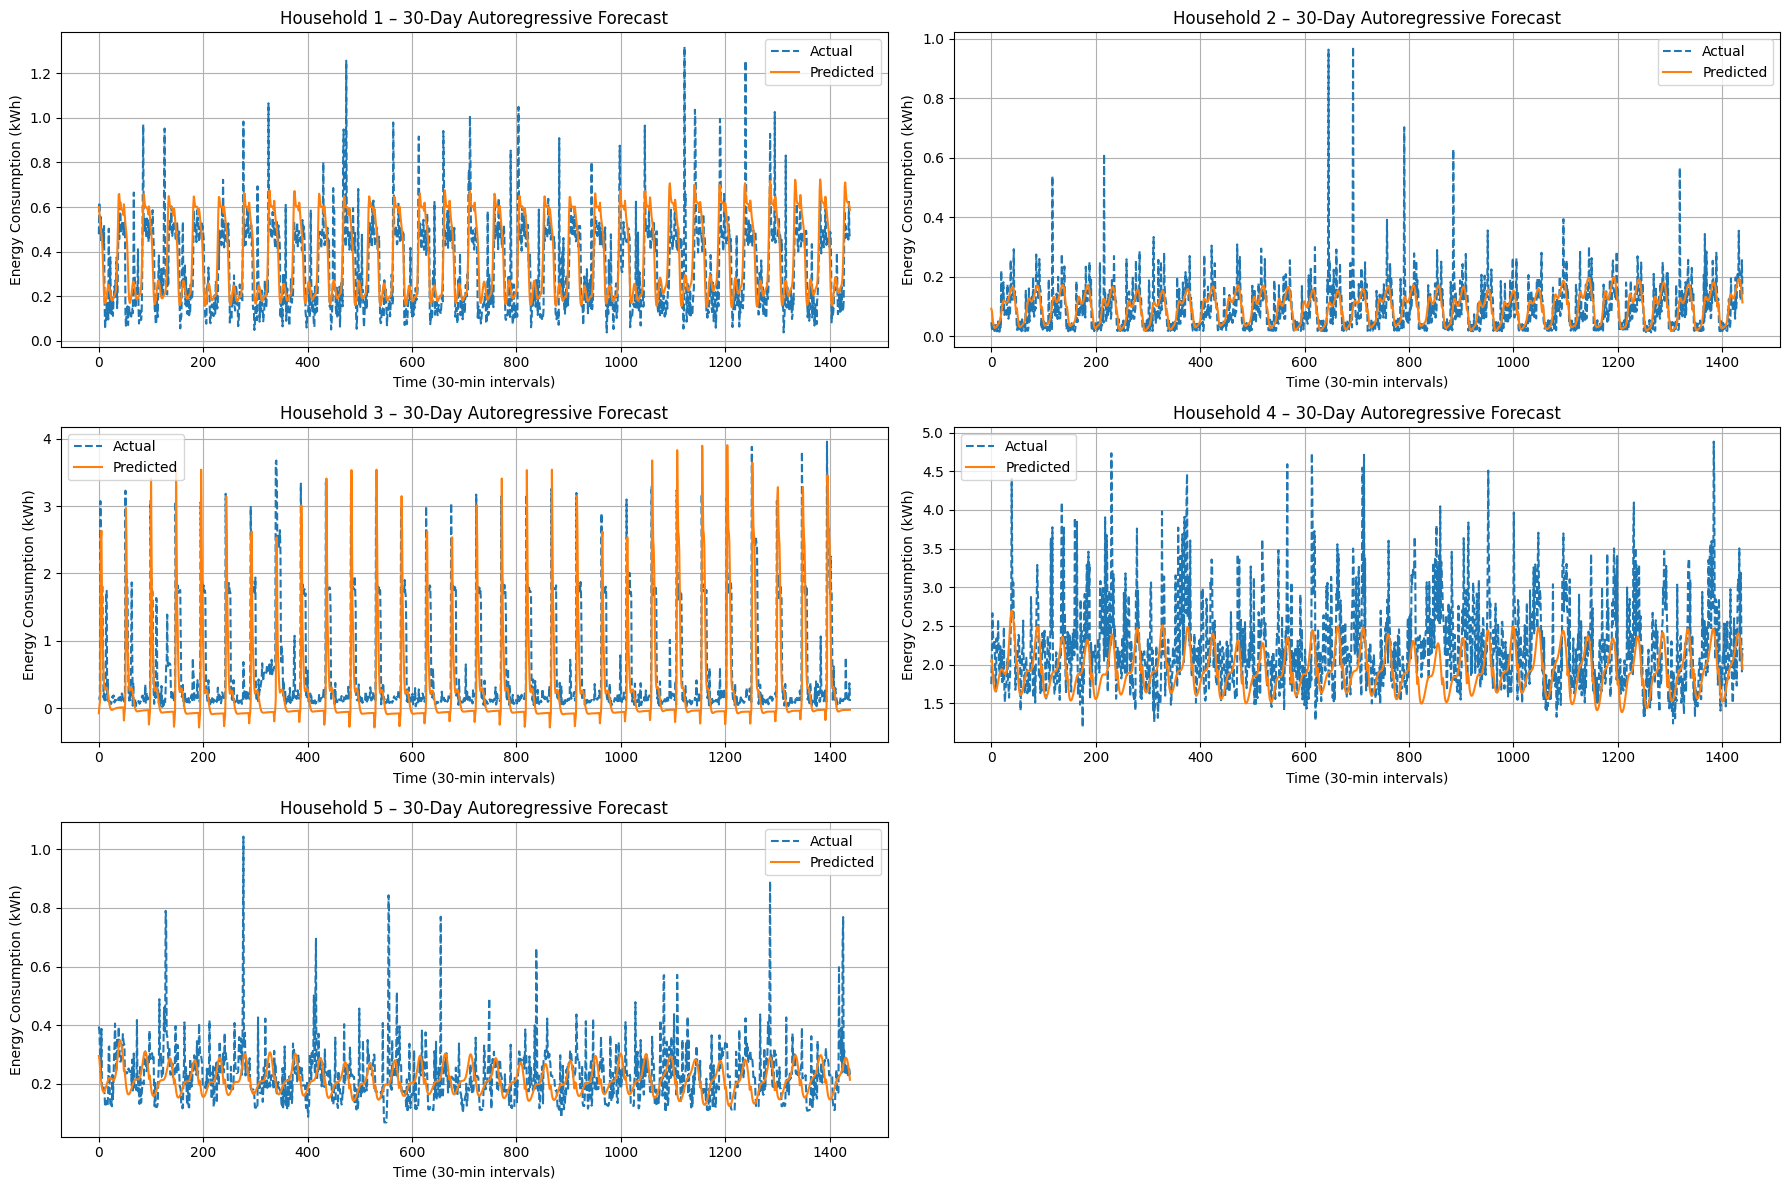

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(18, 12))

for h in range(len(rolling_preds)):
    plt.subplot(3, 2, h + 1)

    y_pred_plot = rolling_preds[h]
    y_true_plot = rolling_truths[h]

    x_axis = np.arange(len(y_true_plot))  # 1440 half-hours

    plt.plot(x_axis, y_true_plot, label='Actual', linestyle='--')
    plt.plot(x_axis, y_pred_plot, label='Predicted', linewidth=1.5)

    plt.title(f'Household {h+1} – 30-Day Autoregressive Forecast')
    plt.xlabel("Time (30-min intervals)")
    plt.ylabel("Energy Consumption (kWh)")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

Next, calculation of autoregressive rolling based fixed 30 days forecast on UNSEEN households:

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def rolling_day_forecast_autoregressive_unseen(series, time_feats, model, input_window=336, horizon=48, total_days=30):
    """
    Autoregressive daily forecast for a single unseen household.
    Predicts 48 steps per day, feeding predictions back into input.

    Args:
        series: 1D numpy array of energy usage (len >= input_window + total_days*horizon)
        time_feats: 2D numpy array of time features (same length as series)
        model: trained forecasting model
        input_window: history window size (default=336 half-hours = 7 days)
        horizon: number of steps per forecast (default=48 = 1 day)
        total_days: number of rolling forecast days (default=30)

    Returns:
        predictions: 1D numpy array of all forecasted values (total_days*horizon)
        actuals: 1D numpy array of corresponding actual values
    """
    # Scale household individually
    scaler_h = MinMaxScaler()
    series_scaled = scaler_h.fit_transform(series.reshape(-1, 1)).flatten()

    predictions = []

    # Initialize with first 7 days of actual data
    curr_input = series_scaled[:input_window].tolist()

    # Ground truth for evaluation
    true_values_full = series_scaled[input_window:input_window + total_days * horizon]

    for i in range(total_days):
        start_idx = i * horizon
        tf_input = time_feats[start_idx:start_idx + input_window]

        # Prepare combined input [energy, time features]
        input_combined = np.hstack([
            np.array(curr_input[-input_window:]).reshape(-1, 1),
            tf_input
        ])

        # Predict 48 steps for the next day
        pred = model.predict(input_combined[np.newaxis, :, :], verbose=0)  # shape (1, horizon, 1)
        pred_flat = pred.reshape(-1)  # shape (horizon,)

        # Append predictions to input sequence for autoregressive step
        curr_input.extend(pred_flat.tolist())

        # Store unscaled prediction
        pred_unscaled = scaler_h.inverse_transform(pred_flat.reshape(-1, 1)).flatten()
        predictions.append(pred_unscaled)

    # Return full predictions and actuals (both unscaled)
    actuals = scaler_h.inverse_transform(true_values_full.reshape(-1, 1)).flatten()
    return np.concatenate(predictions), actuals

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

min_len_required = 336 + 30 * 48
valid_unseen = [col for col in energy_testing_set.columns if len(energy_testing_set[col]) >= min_len_required]

mse_list = []
house_ids = []

for col in valid_unseen:
    series = energy_testing_set[col].values
    tf_unseen = time_features[:len(series)]

    y_pred, y_true = rolling_day_forecast_autoregressive_unseen(series, tf_unseen, model)

    mse = mean_squared_error(y_true, y_pred)
    mse_list.append(mse)
    house_ids.append(col)

    print(f"Household {col}: MSE = {mse:.4f}")

print(f"\n Average Autoregressive MSE (Unseen Households): {np.mean(mse_list):.4f}")

Household uk_MAC003375: MSE = 0.0232
Household uk_MAC004019: MSE = 0.0296
Household uk_MAC003901: MSE = 0.1842
Household uk_MAC002320: MSE = 0.0366
Household uk_MAC002547: MSE = 0.0210
Household uk_MAC001857: MSE = 0.0329
Household uk_MAC003796: MSE = 0.0926
Household uk_MAC003081: MSE = 0.0420
Household uk_MAC000714: MSE = 0.0167
Household uk_MAC003958: MSE = 0.0648
Household uk_MAC001909: MSE = 0.0830
Household uk_MAC000855: MSE = 0.2061
Household uk_MAC001184: MSE = 0.0359
Household uk_MAC002168: MSE = 0.0127
Household uk_MAC005398: MSE = 0.2780
Household uk_MAC003237: MSE = 0.2413
Household uk_MAC005552: MSE = 0.0533
Household uk_MAC003981: MSE = 0.1314
Household uk_MAC001645: MSE = 0.0392
Household uk_MAC000281: MSE = 0.0240
Household uk_MAC000930: MSE = 0.0504
Household uk_MAC003535: MSE = 0.0606
Household uk_MAC004567: MSE = 0.0340
Household uk_MAC004016: MSE = 0.6481
Household uk_MAC005382: MSE = 0.1872
Household uk_MAC004100: MSE = 0.0036
Household uk_MAC004319: MSE = 2.0285
H

# 7 days input 1 day forecast

Firstly, for seen households test set.

In [ ]:
# 7 days input 1 day forecast

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predict on scaled data
y_pred_scaled = model.predict(X_test)

# Setup
num_households = pivot.shape[1]  # 5 households
samples_per_household = len(X_test) // num_households

# Store all true/pred values unscaled
y_true_unscaled_all = []
y_pred_unscaled_all = []

for h in range(num_households):
    # Slice predictions and true labels for this household
    start = h * samples_per_household
    end = (h + 1) * samples_per_household

    y_pred_scaled_h = y_pred_scaled[start:end].reshape(-1, 1)  # (samples * 48, 1)
    y_true_scaled_h = y_test[start:end].reshape(-1, 1)

    # Get column-wise scaler params
    data_min = scaler.data_min_[h]
    data_max = scaler.data_max_[h]

    # Inverse scale
    y_pred_unscaled_h = y_pred_scaled_h * (data_max - data_min) + data_min
    y_true_unscaled_h = y_true_scaled_h * (data_max - data_min) + data_min

    y_pred_unscaled_all.append(y_pred_unscaled_h.flatten())
    y_true_unscaled_all.append(y_true_unscaled_h.flatten())

# Combine all households
y_pred_unscaled_flat = np.concatenate(y_pred_unscaled_all)
y_true_unscaled_flat = np.concatenate(y_true_unscaled_all)

# Accuracy metrics
mae_unscaled = mean_absolute_error(y_true_unscaled_flat, y_pred_unscaled_flat)
mse_unscaled = mean_squared_error(y_true_unscaled_flat, y_pred_unscaled_flat)
rmse_unscaled = np.sqrt(mean_squared_error(y_true_unscaled_flat, y_pred_unscaled_flat))

print(f"MAE (Unscaled):  {mae_unscaled:.4f}")
print(f"MSE (Unscaled): {mse_unscaled:.4f}")
print(f"RMSE (Unscaled): {rmse_unscaled:.4f}")

376/376 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step
MAE (Unscaled):  0.2046
MSE (Unscaled): 0.1937
RMSE (Unscaled): 0.4401


Next, on UNSEEN households.

In [ ]:
# Testing on UNSEEN households (183 that we separated in the beginning)

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Data: unseen households (183)
unseen_households = energy_testing_set.columns
num_unseen = len(unseen_households)

mae_list = []
mse_list = []
rmse_list = []
house_ids = []

for i, col in enumerate(unseen_households):
    series = energy_testing_set[col].values.reshape(-1, 1)

    # Skip short/incomplete series (shouldn't happen in our data)
    if len(series) < (input_window + forecast_horizon):
        continue

    # Scale this household independently
    scaler_h = MinMaxScaler()
    series_scaled = scaler_h.fit_transform(series)

    # Create time features (already built earlier)
    tf_unseen = time_features

    # Create sequences for this household
    X_h, y_h = create_sequences(series_scaled, tf_unseen, input_window, forecast_horizon)

    # Skip if not enough sequences
    if X_h.shape[0] == 0:
        continue

    # Predict
    y_h_pred = model.predict(X_h)

    # Inverse transform
    y_h_pred_unscaled = scaler_h.inverse_transform(y_h_pred.reshape(-1, 1)).flatten()
    y_h_true_unscaled = scaler_h.inverse_transform(y_h.reshape(-1, 1)).flatten()

    # Compute metrics
    mae = mean_absolute_error(y_h_true_unscaled, y_h_pred_unscaled)
    mse= mean_squared_error(y_h_true_unscaled, y_h_pred_unscaled)
    rmse = np.sqrt(mean_squared_error(y_h_true_unscaled, y_h_pred_unscaled))

    # Save results
    mae_list.append(mae)
    mse_list.append(mse)
    rmse_list.append(rmse)
    house_ids.append(col)

    print(f"Household {i+1}/{num_unseen} ({col}): MAE = {mae:.4f}, MSE = {mse:.4f}, RMSE = {rmse:.4f}")

581/581 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
Household 1/183 (uk_MAC003375): MAE = 0.0971, MSE = 0.0189, RMSE = 0.1374
581/581 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Household 2/183 (uk_MAC004019): MAE = 0.1028, MSE = 0.0294, RMSE = 0.1713
581/581 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
Household 3/183 (uk_MAC003901): MAE = 0.1195, MSE = 0.0324, RMSE = 0.1800
581/581 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Household 4/183 (uk_MAC002320): MAE = 0.1151, MSE = 0.0358, RMSE = 0.1891
581/581 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
Household 5/183 (uk_MAC002547): MAE = 0.0977, MSE = 0.0215, RMSE = 0.1465
581/581 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Household 6/183 (uk_MAC001857): MAE = 0.1178, MSE = 0.0292, RMSE = 0.1710
581/581 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
Household 7/183 (uk_MAC003796): MAE = 0.1693, MSE = 0.0844, RMSE = 0.2904
581/581 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Household 8/183 (uk_MAC003081): MAE = 0.1001, MSE = 0.0345, RMSE = 0.1857
581/581 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Household 9/183 (uk_MAC000714): MAE = 0

In [ ]:
# Overall metrics
print("\n Summary over all unseen households:")
print(f"Average MAE: {np.mean(mae_list):.4f}")
print(f"Average MSE: {np.mean(mse_list):.4f}")
print(f"Average RMSE: {np.mean(rmse_list):.4f}")


 Summary over all unseen households:
Average MAE: 0.1346
Average MSE: 0.0657
Average RMSE: 0.2166
